<a href="https://colab.research.google.com/github/Sharu-052897/deep-learning/blob/main/CNN_Multi_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


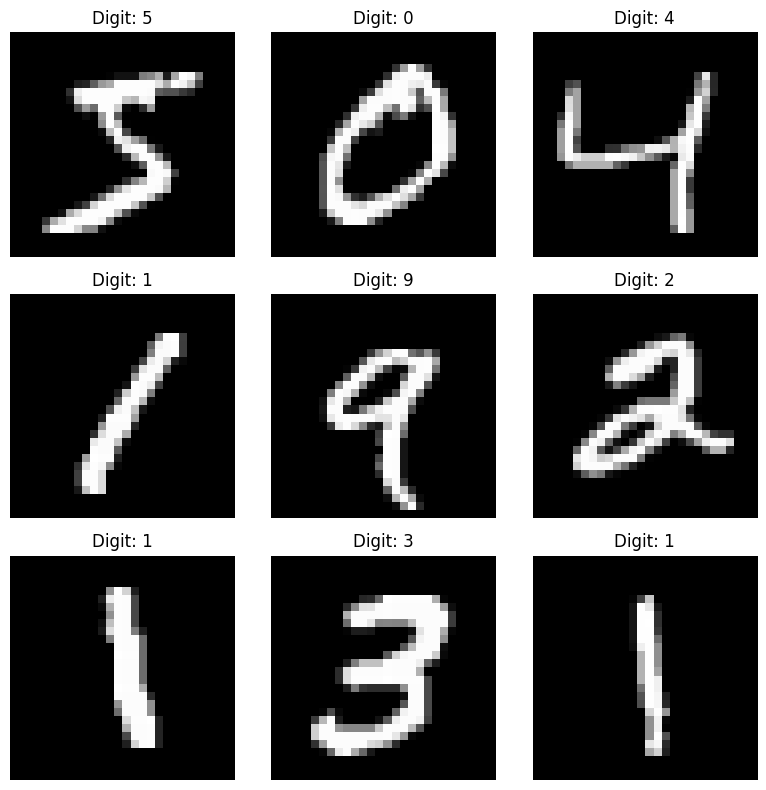

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(X_train[i], cmap="gray")

    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New training shape:", X_train.shape)



New training shape: (60000, 28, 28, 1)


In [ ]:
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=20,
    validation_split=0.2
)

Epoch 1/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - accuracy: 0.9567 - loss: 0.1381 - val_accuracy: 0.9837 - val_loss: 0.0555
Epoch 2/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 53s 22ms/step - accuracy: 0.9859 - loss: 0.0462 - val_accuracy: 0.9863 - val_loss: 0.0473
Epoch 3/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 78s 20ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9874 - val_loss: 0.0412
Epoch 4/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 82s 20ms/step - accuracy: 0.9929 - loss: 0.0211 - val_accuracy: 0.9887 - val_loss: 0.0426
Epoch 5/5
2400/2400 ━━━━━━━━━━━━━━━━━━━━ 82s 21ms/step - accuracy: 0.9940 - loss: 0.0177 - val_accuracy: 0.9904 - val_loss: 0.0347


In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9908 - loss: 0.0294
Test Loss: 0.029380641877651215
Test Accuracy: 0.9908000230789185


In [ ]:
predictions = model.predict(X_test[:9])

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print("Actual digits:")
print(y_test[:9])

print("Predicted digits:")
print(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Actual digits:
[7 2 1 0 4 1 4 9 5]
Predicted digits:
[7 2 1 0 4 1 4 9 5]


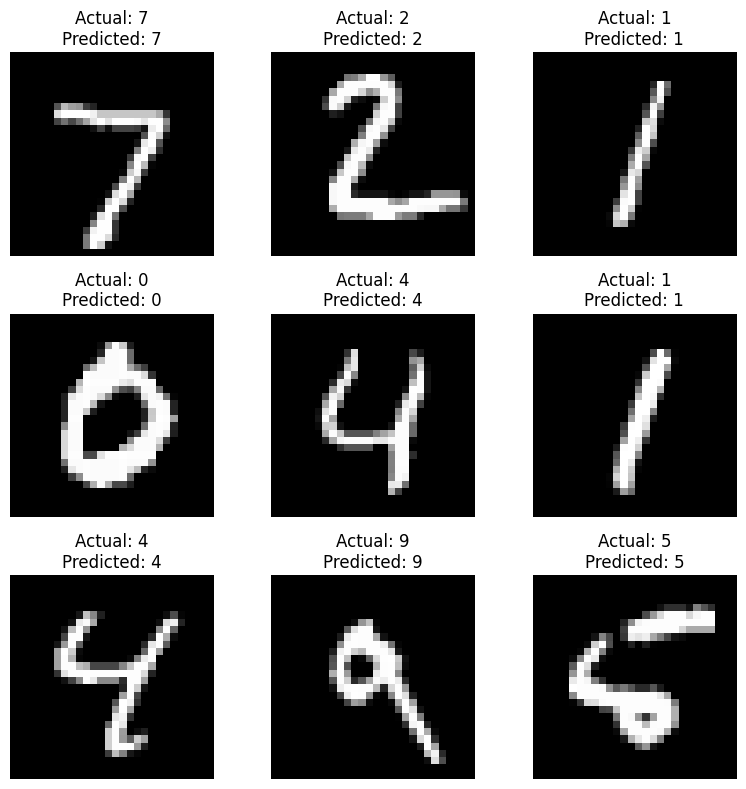

In [ ]:
plt.figure(figsize=(8, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        X_test[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(predicted_classes[i])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

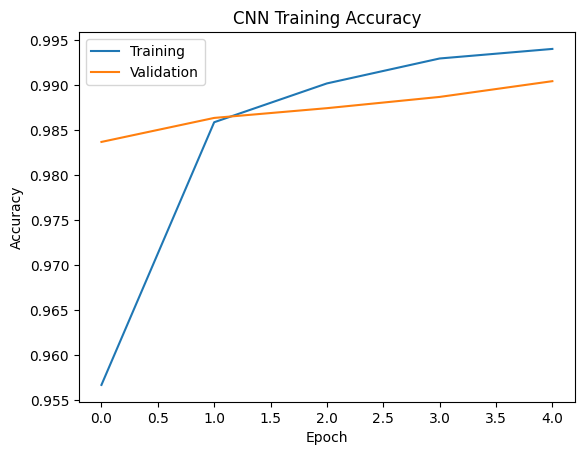

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")

plt.legend([
    "Training",
    "Validation"
])

plt.show()

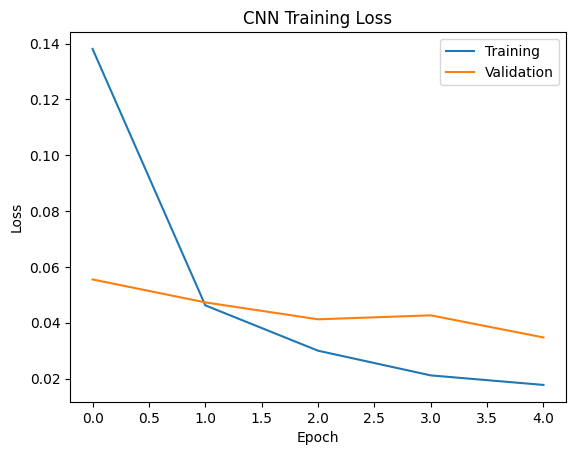

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.legend([
    "Training",
    "Validation"
])

plt.show()